In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("../Dataset/Travel.csv")
df.head()


,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [3]:
df.drop(columns=['CustomerID'], inplace=True)


In [4]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols


(Index(['ProdTaken', 'Age', 'CityTier', 'DurationOfPitch',
        'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar',
        'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar',
        'NumberOfChildrenVisiting', 'MonthlyIncome'],
       dtype='object'),
 Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
        'MaritalStatus', 'Designation'],
       dtype='object'))

In [5]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()


/var/folders/pq/b78qq0pn4c52hb6z8g239wlr0000gn/T/ipykernel_4959/3259374234.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/var/folders/pq/b78qq0pn4c52hb6z8g239wlr0000gn/T/ipykernel_4959/3259374234.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [6]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,1,3,6.0,2,1,3,3.0,1,3.0,2,1.0,1,2,1,0.0,2,20993.0
1,0,49.0,0,1,14.0,2,2,3,4.0,1,4.0,0,2.0,0,3,1,2.0,2,20130.0
2,1,37.0,1,1,8.0,0,2,3,4.0,0,3.0,2,7.0,1,3,0,0.0,1,17090.0
3,0,33.0,0,1,9.0,2,1,2,3.0,0,3.0,0,2.0,1,5,1,1.0,1,17909.0
4,0,36.0,1,1,8.0,3,2,2,3.0,0,4.0,0,1.0,0,5,1,0.0,1,18468.0


In [7]:
X = df.drop(columns=['ProdTaken'])
y = df['ProdTaken']

X.shape, y.shape


((4888, 18), (4888,))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [9]:
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb_clf.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.05, n_estimators=300,
                           random_state=42, subsample=0.8)

In [10]:
y_pred = gb_clf.predict(X_test)
y_pred_proba = gb_clf.predict_proba(X_test)[:, 1]


In [11]:
accuracy_score(y_test, y_pred)

0.8599182004089979

In [12]:
confusion_matrix(y_test, y_pred)


array([[769,  25],
       [112,  72]])

In [13]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.87      0.97      0.92       794
           1       0.74      0.39      0.51       184

    accuracy                           0.86       978
   macro avg       0.81      0.68      0.72       978
weighted avg       0.85      0.86      0.84       978



In [14]:
roc_auc_score(y_test, y_pred_proba)


0.852329974811083

In [15]:
feature_importance = pd.Series(
    gb_clf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)


MonthlyIncome            0.149997
Passport                 0.145773
ProductPitched           0.129909
Age                      0.110250
DurationOfPitch          0.093301
MaritalStatus            0.070764
CityTier                 0.061355
NumberOfFollowups        0.051628
PreferredPropertyStar    0.044512
NumberOfTrips            0.041631
dtype: float64

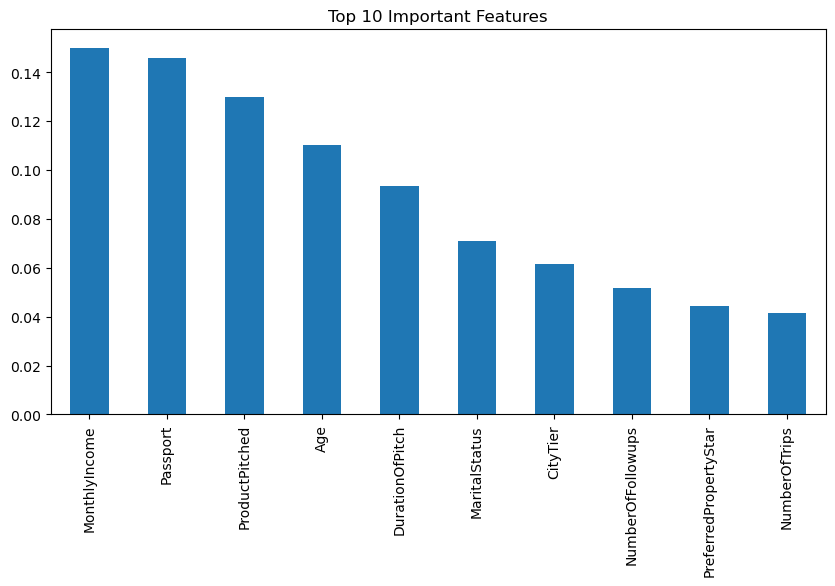

In [16]:
feature_importance.head(10).plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Important Features'
)
plt.show()


In [17]:
sample = X_test.iloc[0].values.reshape(1, -1)

prediction = gb_clf.predict(sample)
probability = gb_clf.predict_proba(sample)

prediction, probability


/Users/harshraj/Desktop/Ml_miniProjects/.conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/Users/harshraj/Desktop/Ml_miniProjects/.conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


(array([1]), array([[0.46074681, 0.53925319]]))